# Calculate the metrics from the csv

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv

# Define models and their respective CSV paths
models_to_test = {
    "DINOv2": "csvs/dinov2_closed_v1/closed_dist_matrix.csv",
    "SwinV2": "csvs/swin_closed_v1/closed_dist_matrix.csv",
    "ViT": "csvs/vit_closed_v1/closed_dist_matrix.csv"
}

all_results = {}

# Run bootstrap for each
for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    all_results[name] = bootstrap_from_csv(path, m=10, mode="closed")


Processing DINOv2


KeyError: 'queryId'

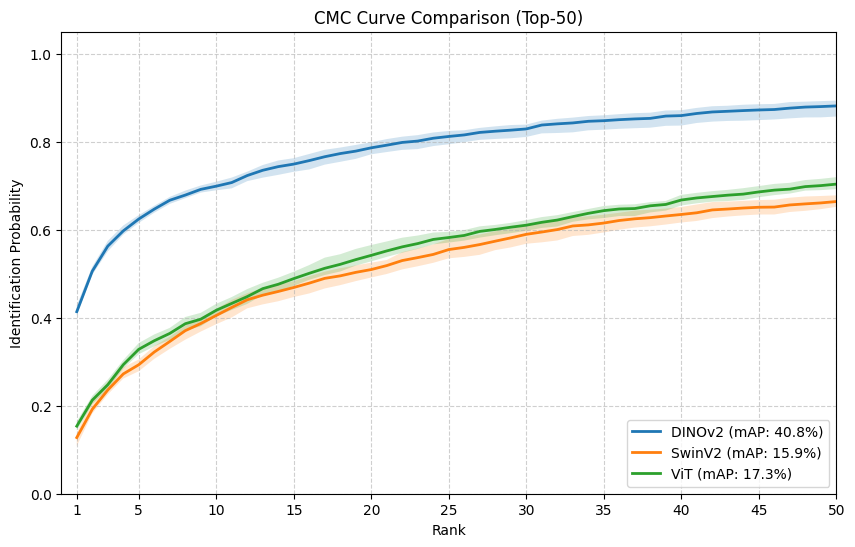

In [13]:
# --- SETTINGS ---
MAX_RANK = 50
TICK_STEP = 5  # This makes labels sparse (shows 1, 10, 20, 30...)

# 2. Plotting the CMC Curves
plt.figure(figsize=(10, 6))

for name, res in all_results.items():
    ranks = res['ranks'][:MAX_RANK]
    mean_cmc = res['cmc_mean'][:MAX_RANK]
    lower = res['cmc_lower'][:MAX_RANK]
    upper = res['cmc_upper'][:MAX_RANK]
    
    plt.plot(ranks, mean_cmc, label=f"{name} (mAP: {res['mAP_mean']:.1%})", lw=2)
    plt.fill_between(ranks, lower, upper, alpha=0.2)

# Formatting
plt.xlabel('Rank')
plt.ylabel('Identification Probability')
plt.title(f'CMC Curve Comparison (Top-{MAX_RANK})')

# Start at 1, go to MAX_RANK, use TICK_STEP. 
# We include [1] explicitly and then the stepped range to ensure Rank-1 always shows.
ticks = [1] + list(np.arange(TICK_STEP, MAX_RANK + 1, TICK_STEP))
plt.xticks(ticks)

plt.grid(ls='--', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim([0, 1.05])
plt.xlim([0, MAX_RANK]) # Ensure the plot starts at Rank 1
plt.show()